In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customizing plot appearance and styles
plt.rcParams['figure.figsize'] = (14, 7)  # Sets the default width and height for all subsequent figures to 14 inches by 7 inches.
plt.style.use('fivethirtyeight')  # Applies the 'fivethirtyeight' stylesheet, which mimics the clean, bold aesthetic of the FiveThirtyEight website.

# Importing display utilities for Jupyter notebooks
from IPython.display import display  # Allows you to explicitly display data structures (like Pandas DataFrames) in a clean, formatted way within Jupyter cells.

In [3]:
df = pd.read_csv('penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
print(df.shape)

(344, 7)


In [5]:
print(df.isnull().sum())

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


In [6]:
max_porcentaje_nulos = (df.isnull().sum() / len(df) * 100).max()
print(f"El porcentaje máximo de nulos en una columna es: {max_porcentaje_nulos:.2f}%")

El porcentaje máximo de nulos en una columna es: 2.91%


In [7]:
df = df.dropna()
df['sex'].unique()


<StringArray>
['MALE', 'FEMALE', '.']
Length: 3, dtype: str

In [8]:
df = df[df['sex'] != '.']
df['sex'].unique()

<StringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str

Visualization

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

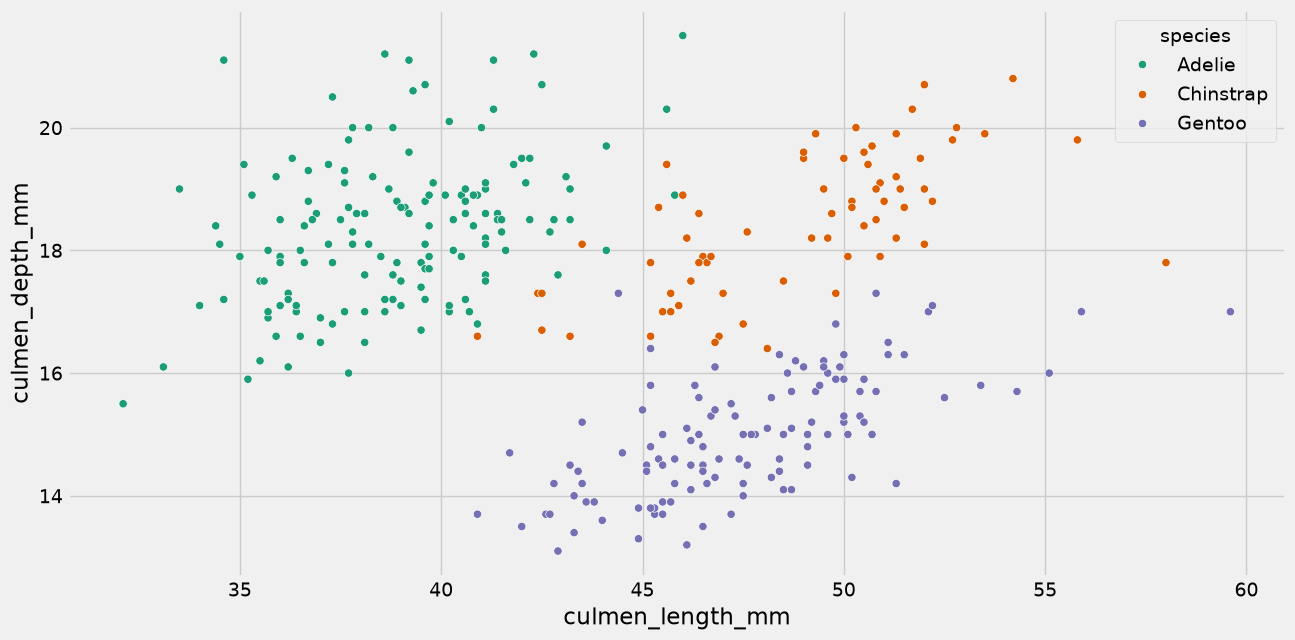

In [9]:
sns.scatterplot(x='culmen_length_mm',y='culmen_depth_mm',data=df,hue='species',palette='Dark2')

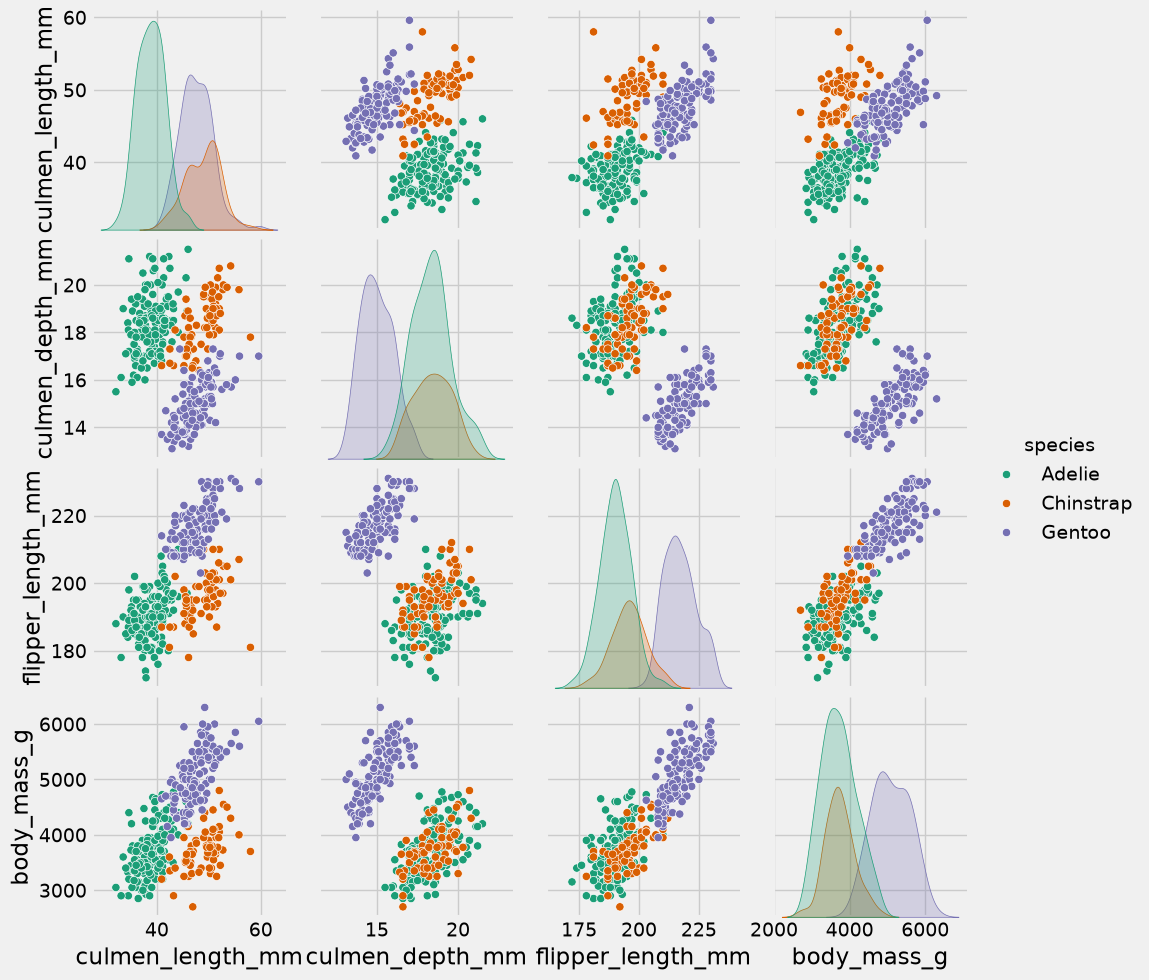

In [10]:
sns.pairplot(df,hue='species',palette='Dark2')

It shows all pairwise relationships between the numeric measurements in the dataset, and each point is colored by species using the Dark2 palette. The diagonal cells show each variable’s distribution, while the off-diagonal cells show scatter plots for every variable pair. In other words, it reflects how the penguin species differ across combinations of measurements.



/tmp/ipykernel_2651/1926922542.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='species',y='culmen_length_mm',data=df,kind='box',col='sex',palette='Dark2')


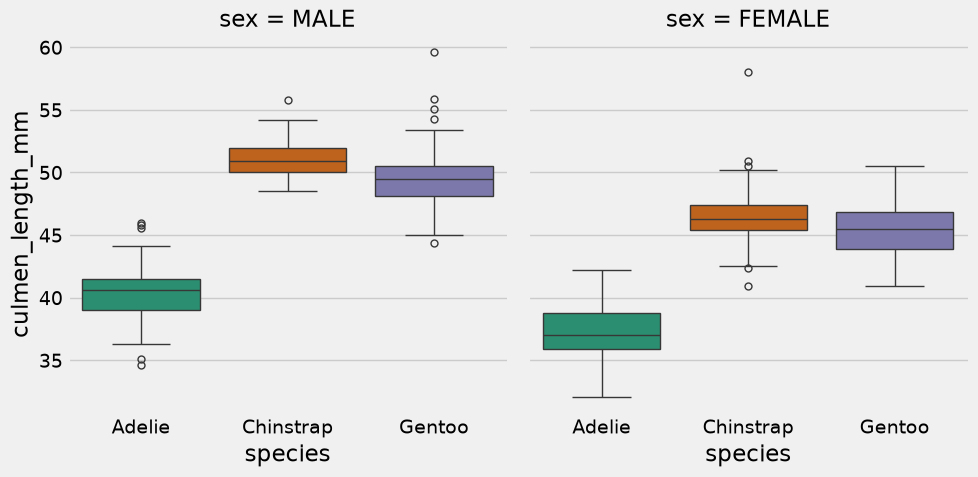

In [11]:
sns.catplot(x='species',y='culmen_length_mm',data=df,kind='box',col='sex',palette='Dark2')

It reflects the distribution of bill length for each penguin species, with boxes showing the middle 50% of values (interquartile range); a line inside each box showing the median; whiskers extending to the typical range of the data; and any points outside that as potential outliers. So it compares bill length across species and shows how that distribution differs between male and female penguins.

In [12]:
pd.get_dummies(df)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,True,False,False,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,True,False,False,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,True,False,False,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,True,False,False,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,True,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,True,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,True,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,True,True,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,True,False,False,True,False


In [13]:
pd.get_dummies(df.drop('species',axis=1),drop_first=True)
#it removes the target column 'species' using the axis=1 and converting all remaining categorical (text) columns into numerical format using One-Hot Encoding (0 and 1).

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


In [14]:
X = pd.get_dummies(df.drop('species',axis=1),drop_first=True)
y = df['species']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=300)

Decision Tree Classifier
Default Hyperparameters

In [15]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

base_pred = model.predict(X_test)

Evaluation

In [16]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay 
confusion_matrix(y_test,base_pred)

array([[41,  2,  0],
       [ 2, 20,  0],
       [ 0,  0, 35]])

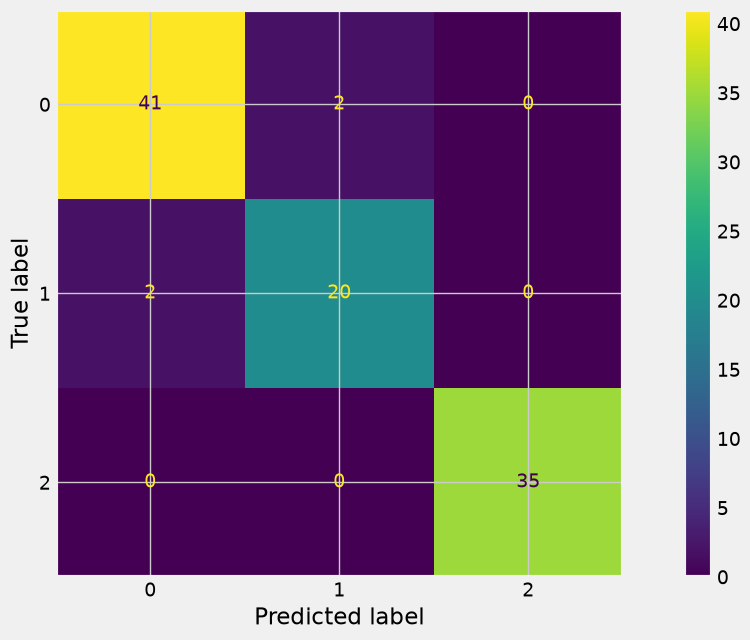

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, base_pred)
ConfusionMatrixDisplay(cm).plot()

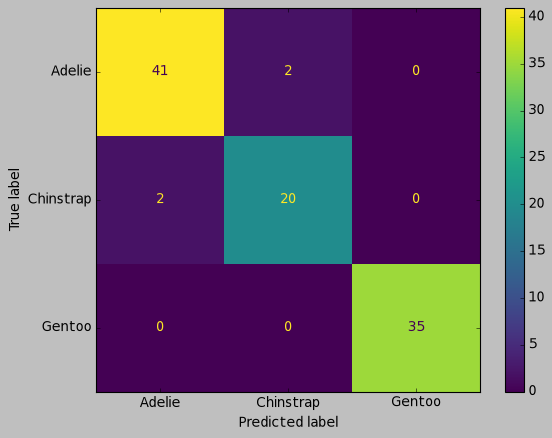

In [19]:
plt.style.use('classic')

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [20]:
print(classification_report(y_test,base_pred))

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        43
   Chinstrap       0.91      0.91      0.91        22
      Gentoo       1.00      1.00      1.00        35

    accuracy                           0.96       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.96      0.96      0.96       100

